# ECB SPF — first look at the HICP panel

Loads all ECB SPF individual-forecast CSVs from `data/ecb/individual_forecasts/`,
extracts the year-on-year HICP inflation expectations, classifies each
`TARGET_PERIOD` string, and tabulates the panel structure (forecaster IDs,
horizons, coverage) before any rank-CI computation. This mirrors the
`EDA.ipynb` step on the Philly side.

To compute MSE-style rank CIs we still need a realization series — a Eurostat
HICP first-release vintage indexed by `target_period`. Once that exists, the
downstream pipeline is identical to the Philly notebooks (`select_top_forecasters`
→ `rank_ci_stepwise_pairwise` → `tau_best_pairwise`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    tau_best_pairwise,
    tau_best_from_rank_ci,
    compute_pairwise,
)
from rankci.data.ecb import (
    INDICATORS,
    load_ecb_csv,
    load_ecb_spf,
    list_survey_csvs,
    add_horizon,
    error_panel,
    load_hicp_realized,
    hicp_realized_by_target_period,
)
from rankci.data.panel import select_top_forecasters

DATA_DIR  = '../../data/ecb/individual_forecasts'
HICP_REAL = '../../data/ecb/prc_hicp_manr__custom_21709551_spreadsheet.xlsx'

## 1. Survey vintages on disk

In [2]:
files = list_survey_csvs(DATA_DIR)
print(f'{len(files)} survey CSVs, {files[0].name} → {files[-1].name}')
print('Indicator sections expected in each CSV:')
for k, v in INDICATORS.items():
    print(f'  {k:9s} {v}')

110 survey CSVs, 1999Q1.csv → 2026Q2.csv
Indicator sections expected in each CSV:
  HICP      INFLATION EXPECTATIONS
  CORE_HICP CORE INFLATION EXPECTATIONS
  RGDP      GROWTH EXPECTATIONS
  UNEMP     EXPECTED UNEMPLOYMENT RATE


## 2. Inspect one vintage

In [3]:
one = load_ecb_csv(files[0])
print(f'{files[0].name} — {len(one)} rows')
print('Indicator counts:')
print(one.indicator.value_counts())
print('\nTarget-period kinds:')
print(one.target_kind.value_counts())
one.head()

1999Q1.csv — 1188 rows
Indicator counts:
indicator
HICP     396
RGDP     396
UNEMP    396
Name: count, dtype: int64

Target-period kinds:
target_kind
year       594
month      396
quarter    198
Name: count, dtype: int64


,survey_year,survey_quarter,indicator,target_period,target_kind,target_year,target_qtr,target_month,forecaster_id,point
0,1999,1,HICP,1999,year,1999,NaN,NaN,1,1.0
1,1999,1,HICP,1999,year,1999,NaN,NaN,2,1.0
2,1999,1,HICP,1999,year,1999,NaN,NaN,3,0.8
3,1999,1,HICP,1999,year,1999,NaN,NaN,4,1.2
4,1999,1,HICP,1999,year,1999,NaN,NaN,5,0.8


## 3. Load HICP across all surveys

In [4]:
hicp = load_ecb_spf(DATA_DIR, indicators=['HICP'])
hicp = add_horizon(hicp)
print(f'HICP rows: {len(hicp):,}')
print(f'Unique forecaster IDs: {hicp.forecaster_id.nunique()}')
print(f'Survey coverage: ({hicp.survey_year.min()},Q{hicp.survey_quarter.min()}) '
      f'→ ({hicp.survey_year.max()},Q{hicp.survey_quarter.max()})')
print(f'Target kinds: {dict(hicp.target_kind.value_counts())}')

HICP rows: 35,314
Unique forecaster IDs: 114
Survey coverage: (1999,Q1) → (2026,Q4)
Target kinds: {'year': 22898, 'month': 12416}


## 4. Horizon distribution

Horizons are signed integer quarters from survey to target. The ECB short-run
panel has 0–7-quarter horizons; the long-term (5-year-ahead) block sits at
~18–21 quarters.

In [5]:
h_dist = (hicp[hicp.horizon_q.notna()]
          .groupby('horizon_q').size()
          .rename('n_forecasts'))
print(h_dist.to_string())

horizon_q
0.0     1584
1.0     1462
2.0     1620
3.0     7841
4.0     1584
5.0     1462
6.0     1619
7.0     7729
8.0     1497
9.0     1381
10.0     752
11.0     773
18.0    1458
19.0    1816
20.0    1411
21.0    1325


## 5. Forecaster coverage

How many surveys does each forecaster show up in (any horizon)?

In [6]:
surveys_per_fid = (hicp.drop_duplicates(['forecaster_id', 'survey_year', 'survey_quarter'])
                       .groupby('forecaster_id').size()
                       .sort_values(ascending=False))
print(f'Forecasters with ≥ 20 survey appearances: {(surveys_per_fid >= 20).sum()}')
print(f'Forecasters with ≥ 50 survey appearances: {(surveys_per_fid >= 50).sum()}')
print(f'Forecasters with ≥ 80 survey appearances: {(surveys_per_fid >= 80).sum()}')
print('\nTop 15 by coverage:')
print(surveys_per_fid.head(15))

Forecasters with ≥ 20 survey appearances: 92
Forecasters with ≥ 50 survey appearances: 64
Forecasters with ≥ 80 survey appearances: 35

Top 15 by coverage:
forecaster_id
95    108
41    108
93    107
32    106
89    106
37    105
15    104
7     104
39    104
16    104
23    102
20    101
24    101
47    101
14    100
dtype: int64


## 6. Realized HICP from Eurostat

`prc_hicp_manr__custom_21709551_spreadsheet.xlsx` is the Eurostat dataset of
monthly year-on-year HICP inflation for the Euro area (1997-01 onwards).
`hicp_realized_by_target_period` converts it into a Series keyed by exactly
the ECB SPF `TARGET_PERIOD` strings, so it slots into `error_panel` directly:

- `"YYYY"` → mean of 12 monthly YoY rates that year
- `"YYYYMon"` → the YoY rate of that specific month
- `"YYYYQq"` → mean of the 3 monthly YoY rates in that quarter

In [7]:
monthly = load_hicp_realized(HICP_REAL)
print(f'Eurostat HICP YoY: {len(monthly)} monthly obs, '
      f'{monthly.index.min()} → {monthly.index.max()}')

realized = hicp_realized_by_target_period(monthly)
print(f'Realized series, total target_period keys: {len(realized)}')

# A few sanity-check spot reads
for k in ['2003', '2003Sep', '2003Q4', '2008', '2020', '2020Mar', '2020Q2', '2025']:
    val = realized.get(k)
    print(f'  {k:10s} -> {val:.2f}' if val is not None else f'  {k:10s} -> (missing)')

Eurostat HICP YoY: 348 monthly obs, 1997-01 → 2025-12
Realized series, total target_period keys: 493
  2003       -> 2.08
  2003Sep    -> 2.10
  2003Q4     -> 2.07
  2008       -> 3.28
  2020       -> 0.25
  2020Mar    -> 0.70
  2020Q2     -> 0.23
  2025       -> 2.13


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 7. Squared-error panel and rank CIs

We compute MSE rankings on the **annual** target ("YYYY") at horizon `h=3`
quarters (one-year-ahead forecasts of the next-calendar-year average inflation
rate, which is the canonical ECB SPF block). Then `select_top_forecasters` →
`rank_ci_stepwise_pairwise`, exactly as on the Philly notebooks.

In [8]:
TARGET_KIND = 'year'    # 'year' | 'month' | 'quarter'
HORIZON_Q   = 3         # quarters from survey to target
METRIC      = 'squared' # 'squared' or 'absolute'
N           = 8
MIN_OBS     = 15

X_wide = error_panel(
    hicp, realized,
    indicator='HICP', target_kind=TARGET_KIND,
    horizon_q=HORIZON_Q, metric=METRIC,
)
print(f'Wide panel: {X_wide.shape[0]} targets × {X_wide.shape[1]} forecasters')

obs_counts = X_wide.notna().sum()
print(f'  ≥ {MIN_OBS} obs: {(obs_counts >= MIN_OBS).sum()} forecasters')
print(f'  ≥ 20 obs: {(obs_counts >= 20).sum()} forecasters')

X_panel = select_top_forecasters(X_wide, N=N, min_obs=MIN_OBS)
print(f'\nSelected top-{N}: {X_panel.shape[0]} targets, IDs={X_panel.columns.tolist()}')

Wide panel: 27 targets × 112 forecasters
  ≥ 15 obs: 58 forecasters
  ≥ 20 obs: 39 forecasters

Selected top-8: 27 targets, IDs=[16, 32, 39, 89, 95, 15, 20, 23]


In [9]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    'ID':       population_ids,
    'MSE':      out['theta_hat'].round(4),
    'RMSE':     np.sqrt(out['theta_hat']).round(4),
    'CI_lower': out['rank_ci'][:, 0],
    'CI_upper': out['rank_ci'][:, 1],
}).sort_values('MSE')
results.index = range(1, len(results) + 1)
results.index.name = 'Rank'
results

=== Pairwise shared observations ===
  Min: 25, Mean: 26.2, Max: 27
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 2.3774, Pairs with t > 1.96: 1


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,95,1.1534,1.0740,1,8
2,39,1.1818,1.0871,1,8
3,20,1.2082,1.0992,1,8
4,16,1.3031,1.1415,1,8
5,23,1.4104,1.1876,1,8
6,32,1.4721,1.2133,1,8
7,89,1.5694,1.2527,1,8
8,15,1.6861,1.2985,1,8


## 8. Worst-target diagnostic

Which years drive the squared error? Useful to confirm 2008 / 2020-2022
(GFC, COVID, post-COVID inflation surge) dominate the loss, the same
crisis-tail pattern that makes the Philly CIs uninformative.

Top 10 targets with highest average squared error:
target_period
2022    26.956
2021     2.616
2020     0.989
2008     0.686
2011     0.598
2014     0.517
2016     0.510
2012     0.500
2023     0.491
2009     0.430
dtype: float64


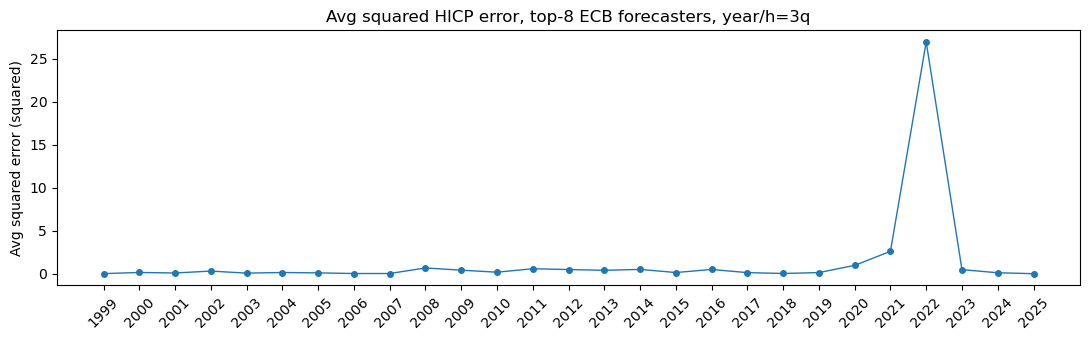

In [10]:
period_mse = X_panel.mean(axis=1)
print('Top 10 targets with highest average squared error:')
print(period_mse.nlargest(10).round(3))

plt.figure(figsize=(11, 3.5))
plt.plot(X_panel.index, period_mse, marker='o', linewidth=1, markersize=4)
plt.xticks(rotation=45)
plt.ylabel(f'Avg squared error ({METRIC})')
plt.title(f'Avg squared HICP error, top-{N} ECB forecasters, '
          f'{TARGET_KIND}/h={HORIZON_Q}q')
plt.tight_layout()
plt.show()

## 9. Marginal CIs

For comparison: per-forecaster CIs that control coverage only marginally
(no joint family-wise error control). They are tighter than the simultaneous
stepwise CIs but don't deliver a joint guarantee.

In [11]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    'ID':       population_ids,
    'MSE':      out_marg['theta_hat'].round(4),
    'RMSE':     np.sqrt(out_marg['theta_hat']).round(4),
    'cv_j':     out_marg['critical_values'].round(3),
    'CI_lower': out_marg['rank_ci'][:, 0],
    'CI_upper': out_marg['rank_ci'][:, 1],
}).sort_values('MSE')
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = 'Rank'
results_marg

,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,95,1.1534,1.0740,2.758,1,8
2,39,1.1818,1.0871,2.809,1,8
3,20,1.2082,1.0992,2.723,1,8
4,16,1.3031,1.1415,3.268,1,8
5,23,1.4104,1.1876,3.568,1,8
6,32,1.4721,1.2133,3.587,1,8
7,89,1.5694,1.2527,3.298,1,8
8,15,1.6861,1.2985,2.880,1,8


## 10. τ-best confidence set

Same Algorithm 3.3 as in `Reports/tau_best_report.tex`, applied to ECB HICP.
For each $\tau \in \{1,2,3\}$ we report the forecasters that *cannot* be ruled
out of the truly top-$\tau$ at $\alpha = 0.2$.

In [12]:
ALPHA_TAU = 0.2
B_TAU     = 5000
SEED_TAU  = 42

out_rank = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows = []
for tau in [1, 2, 3]:
    res   = tau_best_pairwise(X, tau=tau, alpha=ALPHA_TAU, B=B_TAU,
                              seed=SEED_TAU, verbose=False)
    naive = tau_best_from_rank_ci(out_rank['rank_ci'], tau=tau)
    rows.append({
        'tau':           tau,
        'n_direct':      int(res['n_in_set']),
        'set_direct':    [population_ids[j] for j, v in enumerate(res['tau_best_set']) if v],
        'n_naive':       int(naive.sum()),
        'set_naive':     [population_ids[j] for j, v in enumerate(naive) if v],
        'max_test_stat': round(float(np.nanmax(res['test_stats'])), 3),
    })

tau_sweep = pd.DataFrame(rows).set_index('tau')
print(f'alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(population_ids)}')
print(f'Forecaster IDs: {population_ids}')
print()
tau_sweep

alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [16, 32, 39, 89, 95, 15, 20, 23]



,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.377
2,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",1.758
3,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",1.564


## 11. Pre-COVID subsample (targets before 2021)

Section 8 showed that 2022 alone contributes a squared error of ~27 pp² —
~10× the next worst year — driven by the post-pandemic inflation surge that
ECB SPF panelists could not foresee. That tail dominates both the mean MSE
and the pairwise standard error denominator, so its presence kneecaps
$\max|t_{jk}|$ on the full sample.

Here we re-run the same `select_top_forecasters → rank_ci_stepwise_pairwise →
tau_best_pairwise` chain on the panel restricted to target periods strictly
before 2021. Same indicator, same horizon, same `N`, same `MIN_OBS`. If the
COVID-2021/22 surge is what's killing informativeness, this restricted panel
should give a noticeably larger $\max|t|$ and a tighter rank CI; if it isn't
(i.e. the forecasters genuinely cluster too tightly even in calm times), the
picture won't change much.

In [13]:
# Restrict to target periods strictly before 2021, keeping the SAME top-N
# forecasters that were chosen on the full sample (population_ids from §7).
# This isolates the effect of the COVID-era targets from any change in which
# forecasters get selected.
CUTOFF_YEAR = 2021

target_year = pd.to_numeric(X_wide.index.astype(str).str.slice(0, 4),
                            errors='coerce')
mask_pre    = target_year < CUTOFF_YEAR

X_panel_pre = X_panel.loc[mask_pre]
X_pre       = X_panel_pre.values
ids_pre     = X_panel_pre.columns.tolist()
assert ids_pre == population_ids   # same forecasters by construction

dropped = [t for t in X_panel.index if t not in X_panel_pre.index]
print(f'Full sample:    {X_panel.shape[0]} targets, IDs={population_ids}')
print(f'Pre-{CUTOFF_YEAR} sample: {X_panel_pre.shape[0]} targets, IDs={ids_pre}')
print(f'Targets dropped: {dropped}')
print(f'Per-forecaster obs counts in pre-{CUTOFF_YEAR}:')
print(X_panel_pre.notna().sum().to_dict())

Full sample:    27 targets, IDs=[16, 32, 39, 89, 95, 15, 20, 23]
Pre-2021 sample: 22 targets, IDs=[16, 32, 39, 89, 95, 15, 20, 23]
Targets dropped: ['2021', '2022', '2023', '2024', '2025']
Per-forecaster obs counts in pre-2021:
{16: 22, 32: 22, 39: 22, 89: 22, 95: 22, 15: 21, 20: 21, 23: 21}


In [18]:
# Rank CI on the pre-2021 panel
out_pre = rank_ci_stepwise_pairwise(X_pre, alpha=0.2, B=5000, seed=42)

results_pre = pd.DataFrame({
    'ID':       ids_pre,
    'MSE':      out_pre['theta_hat'].round(4),
    'RMSE':     np.sqrt(out_pre['theta_hat']).round(4),
    'CI_lower': out_pre['rank_ci'][:, 0],
    'CI_upper': out_pre['rank_ci'][:, 1],
}).sort_values('MSE')
results_pre.index = range(1, len(results_pre) + 1)
results_pre.index.name = 'Rank'
results_pre

=== Pairwise shared observations ===
  Min: 20, Mean: 21.2, Max: 22
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 2.9104, Pairs with t > 1.96: 7


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,16,0.2059,0.4538,1,7
2,39,0.2099,0.4582,1,8
3,20,0.2629,0.5128,1,8
4,23,0.2771,0.5264,1,8
5,32,0.3097,0.5565,1,8
6,15,0.3134,0.5598,1,8
7,95,0.3675,0.6062,2,8
8,89,0.3911,0.6254,1,8


In [15]:
# Side-by-side informativeness summary: full vs pre-2021
def _summary(X_arr, label, alpha=0.05, B=5000, seed=42):
    delta, se, n_pairs = compute_pairwise(X_arr, se_method='nw')
    t = np.abs(delta / se)
    valid = np.isfinite(t)
    tv = t[valid]
    n_obs = (~np.isnan(X_arr)).sum(axis=0)
    theta = np.nanmean(X_arr, axis=0)
    out_ci = rank_ci_stepwise_pairwise(X_arr, alpha=alpha, B=B,
                                       seed=seed, verbose=False)
    widths = out_ci['rank_ci'][:, 1] - out_ci['rank_ci'][:, 0] + 1
    return {
        'sample':            label,
        'n_targets':         X_arr.shape[0],
        'p':                 X_arr.shape[1],
        'min_overlap':       int(n_pairs[n_pairs > 0].min()),
        'med_overlap':       int(np.median(n_pairs[n_pairs > 0])),
        'theta_min':         float(theta.min()),
        'theta_max':         float(theta.max()),
        'theta_max/min':     float(theta.max() / theta.min()),
        'max_|t|':           float(tv.max()),
        '%_|t|>1.96':        float((tv > 1.96).mean() * 100),
        '%_|t|>3':           float((tv > 3.0).mean() * 100),
        'CI_mean_width':     float(widths.mean()),
        'CI_max_width':      int(widths.max()),
        'CI_#singletons':    int((widths == 1).sum()),
        'CI_full':           bool(widths.max() == X_arr.shape[1]),
    }

summary = pd.DataFrame([
    _summary(X,     'full (1999-2025)'),
    _summary(X_pre, f'pre-{CUTOFF_YEAR}     '),
]).set_index('sample').T
with pd.option_context('display.float_format', '{:.3g}'.format):
    print(summary)

sample         full (1999-2025) pre-2021     
n_targets                    27            22
p                             8             8
min_overlap                  25            20
med_overlap                  26            21
theta_min                  1.15         0.206
theta_max                  1.69         0.391
theta_max/min              1.46           1.9
max_|t|                    2.38          2.91
%_|t|>1.96                 3.57            25
%_|t|>3                       0             0
CI_mean_width                 8             8
CI_max_width                  8             8
CI_#singletons                0             0
CI_full                    True          True


In [16]:
# τ-best on pre-2021 panel — same forecasters as full sample (§10)
out_rank_pre = rank_ci_stepwise_pairwise(
    X_pre, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows_pre = []
for tau in [1, 2, 3]:
    res   = tau_best_pairwise(X_pre, tau=tau, alpha=ALPHA_TAU, B=B_TAU,
                              seed=SEED_TAU, verbose=False)
    naive = tau_best_from_rank_ci(out_rank_pre['rank_ci'], tau=tau)
    rows_pre.append({
        'tau':           tau,
        'n_direct':      int(res['n_in_set']),
        'set_direct':    [ids_pre[j] for j, v in enumerate(res['tau_best_set']) if v],
        'n_naive':       int(naive.sum()),
        'set_naive':     [ids_pre[j] for j, v in enumerate(naive) if v],
        'max_test_stat': round(float(np.nanmax(res['test_stats'])), 3),
    })

tau_sweep_pre = pd.DataFrame(rows_pre).set_index('tau')
print(f'Pre-{CUTOFF_YEAR} sample — alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(ids_pre)}')
print(f'Forecaster IDs: {ids_pre}')
print()
print(tau_sweep_pre.to_string())
tau_sweep_pre

Pre-2021 sample — alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [16, 32, 39, 89, 95, 15, 20, 23]

     n_direct                        set_direct  n_naive                         set_naive  max_test_stat
tau                                                                                                      
1           7      [16, 32, 39, 89, 15, 20, 23]        7      [16, 32, 39, 89, 15, 20, 23]          2.910
2           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.667
3           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.098


,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,7,"[16, 32, 39, 89, 15, 20, 23]",7,"[16, 32, 39, 89, 15, 20, 23]",2.910
2,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.667
3,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.098


### Verdict — does dropping COVID make the CIs informative?

Use the side-by-side table above to read off the answer. The relevant comparisons:

- **Mean MSE level** (`theta_min`, `theta_max`): how tight are the forecasters?
- **`theta_max/min`**: dispersion across forecasters. Note that the *level* of
  MSE falls sharply on pre-2021 (it no longer includes the 26.96 pp² 2022 hit),
  but the dispersion ratio may go up because all forecasters get smaller MSEs.
- **`max_|t|`**: must exceed the stepwise critical value (~3.0 for $\alpha=0.05$,
  $p=8$ — closer to 3.5–3.7 from the bootstrap distribution) for the joint
  rank CI to do anything.
- **`%_|t|>1.96`** and **`%_|t|>3`**: how much "signal mass" exists in the pairwise
  comparisons.
- **`CI_#singletons`** and **`CI_full`**: the bottom line. A `CI_full=True` panel
  still returns $[1, p]$ for every forecaster.

If `max_|t|` rises but the rank CI is still trivial, the conclusion is that
COVID exacerbated the problem but the underlying ECB SPF top-8 simply clusters
too tightly even in calm years to be separated by 22 annual observations.